# Credit Card Transactions — RFM Segmentation & Customer Clustering
**Project:** Customer Spending Intelligence | Fintech Portfolio Project
**Phase:** 2 of 4 — RFM Segmentation (K-Means Clustering)
**Input:** `customer_aggregated.csv` (983 customers × 22 features, output of Phase 1)
**Output:** `customer_segments.csv` — cluster labels appended, ready for Phase 3 modeling
**Author:** Shrey Sheth

---

## What this notebook does
1. Preprocesses the customer-level RFM table (log-transform skewed features, StandardScaler)
2. Selects the optimal number of clusters k via Elbow curve + Silhouette analysis
3. Fits K-Means and assigns each customer to a segment
4. Reduces to 2D via PCA and t-SNE for visual validation
5. Profiles each cluster with radar charts and a business narrative
6. Exports `customer_segments.csv` for Phase 3

> **Why RFM?** Recency, Frequency, and Monetary value are the three behavioural axes that best predict customer lifetime value, churn risk, and fraud propensity. Segmenting customers along these axes gives us actionable groups — not just model inputs.


---
## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)
np.random.seed(42)

print('Setup complete.')


Setup complete.


---
## 1. Load Customer-Level Data

> This is the 983-row aggregated customer table built in Phase 1. Each row is one credit card account with RFM features, behavioral aggregates, and a fraud flag.

In [2]:
df = pd.read_csv('customer_aggregated.csv')
print(f'Shape: {df.shape}')
print(f'Fraud-flagged customers: {df["fraud_flag"].sum()} ({df["fraud_flag"].mean()*100:.1f}%)')
df.head()


Shape: (983, 22)
Fraud-flagged customers: 762 (77.5%)


,cc_num,recency,frequency,monetary,avg_txn_amt,max_txn_amt,std_txn_amt,unique_merchants,unique_states,unique_categories,night_txn_count,weekend_txn_count,avg_distance_km,fraud_flag,fraud_txn_count,gender,state,customer_age,city_pop,job,night_txn_pct,weekend_txn_pct
0,60416207185,0,1518,"85,043.470",56.023,"3,075.090",122.633,575,1,14,226,495,73.804,1,9,F,WY,32,1645,Information systems manager,0.149,0.326
1,60422928733,0,1531,"105,640.200",69.001,"1,290.370",102.682,578,1,14,469,516,79.173,1,12,M,SC,76,46944,Secondary school teacher,0.306,0.337
2,60423098130,2,510,"58,673.630",115.046,"27,119.770","1,202.988",338,1,14,111,171,77.279,1,10,M,OK,60,83,Barrister's clerk,0.218,0.335
3,60427851591,1,528,"59,129.610",111.988,"1,164.360",143.311,358,1,14,114,166,75.219,1,14,M,OK,42,2142,Politician's assistant,0.216,0.314
4,60487002085,0,496,"25,160.110",50.726,750.390,65.844,346,1,14,77,160,79.565,0,0,M,MS,46,233060,"Horticulturist, commercial",0.155,0.323


In [3]:
# Confirm key RFM columns are present
rfm_cols = ['recency', 'frequency', 'monetary']
behavioral_cols = ['avg_txn_amt', 'max_txn_amt', 'std_txn_amt',
                   'night_txn_pct', 'weekend_txn_pct', 'avg_distance_km',
                   'unique_merchants', 'unique_states', 'unique_categories']

print('RFM columns present:', all(c in df.columns for c in rfm_cols))
print('Behavioral columns present:', all(c in df.columns for c in behavioral_cols))
print()
print(df[rfm_cols + behavioral_cols].describe().T[['mean','std','min','50%','max']])


RFM columns present: True
Behavioral columns present: True

                        mean        std       min        50%         max
recency               21.177     87.080     0.000      0.000     534.000
frequency          1,319.100    812.236     7.000  1,054.000   3,123.000
monetary          92,800.029 59,584.779 1,348.530 88,514.240 296,436.730
avg_txn_amt          110.995    146.596    42.952     67.558     948.818
max_txn_amt        2,768.811  3,077.139   332.350  1,673.890  28,948.900
std_txn_amt          159.114    104.351    60.247    123.936   1,202.988
night_txn_pct          0.217      0.082     0.000      0.225       0.857
weekend_txn_pct        0.349      0.119     0.000      0.343       1.000
avg_distance_km       76.122      3.460    54.786     75.932      98.999
unique_merchants     487.357    174.673     6.000    524.000     678.000
unique_states          1.000      0.000     1.000      1.000       1.000
unique_categories     13.314      2.406     2.000     14.000    

---
## 2. Preprocessing

> **Key decisions:**
> - `monetary`, `frequency`, `max_txn_amt`, `std_txn_amt`, `unique_merchants` are right-skewed — apply `log1p` to compress the long tail
> - `StandardScaler` after log-transform so K-Means distance calculations are not dominated by any single feature
> - Keep `fraud_flag` out of clustering inputs — it's a label we'll use for validation after the fact, not a feature we want to cluster on


In [4]:
# Features to use for clustering
cluster_features = rfm_cols + behavioral_cols

# Identify which features need log-transform (skewness > 1)
skew = df[cluster_features].skew().sort_values(ascending=False)
print('Feature skewness (pre-transform):')
print(skew.round(2))


Feature skewness (pre-transform):
recency              4.470
max_txn_amt          3.900
std_txn_amt          3.620
avg_txn_amt          3.580
weekend_txn_pct      2.120
night_txn_pct        1.190
monetary             0.830
frequency            0.350
avg_distance_km      0.120
unique_states        0.000
unique_merchants    -1.440
unique_categories   -3.290
dtype: float64


In [5]:
# Apply log1p to heavily skewed features
log_features = skew[skew > 1].index.tolist()
print(f'Applying log1p to: {log_features}')

df_proc = df[cluster_features].copy()
df_proc[log_features] = np.log1p(df_proc[log_features])

# Verify skewness improved
skew_after = df_proc.skew().sort_values(ascending=False)
comparison = pd.DataFrame({'before': skew, 'after': skew_after}).round(2)
print()
print('Skewness before vs after log-transform:')
print(comparison)


Applying log1p to: ['recency', 'max_txn_amt', 'std_txn_amt', 'avg_txn_amt', 'weekend_txn_pct', 'night_txn_pct']

Skewness before vs after log-transform:
                   before  after
avg_distance_km     0.120  0.120
avg_txn_amt         3.580  2.790
frequency           0.350  0.350
max_txn_amt         3.900  0.890
monetary            0.830  0.830
night_txn_pct       1.190  0.720
recency             4.470  3.180
std_txn_amt         3.620  1.330
unique_categories  -3.290 -3.290
unique_merchants   -1.440 -1.440
unique_states       0.000  0.000
weekend_txn_pct     2.120  0.340


In [6]:
# StandardScaler — zero mean, unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_proc)
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print(f'Scaled feature matrix: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(3)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0).round(3)}')


Scaled feature matrix: (983, 12)
Mean (should be ~0): [-0. -0. -0.  0. -0. -0. -0.  0. -0.  0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]


---
## 3. Optimal k Selection

> We use two complementary methods:
> - **Elbow curve**: plot inertia (within-cluster sum of squares) vs k — look for the "elbow" where improvement flattens
> - **Silhouette score**: measures how well each point fits its own cluster vs neighbouring clusters — ranges from -1 to +1, higher is better
>
> When both methods agree on the same k, that's the confident choice. If they differ slightly, prefer the silhouette score — it has a clearer interpretation.


In [7]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'k={k:2d}  |  inertia={km.inertia_:,.0f}  |  silhouette={silhouette_score(X_scaled, labels):.4f}')


k= 2  |  inertia=6,550  |  silhouette=0.6580
k= 3  |  inertia=5,055  |  silhouette=0.2888
k= 4  |  inertia=4,225  |  silhouette=0.2980
k= 5  |  inertia=3,587  |  silhouette=0.2960
k= 6  |  inertia=3,223  |  silhouette=0.2493
k= 7  |  inertia=2,958  |  silhouette=0.2465
k= 8  |  inertia=2,763  |  silhouette=0.2330
k= 9  |  inertia=2,579  |  silhouette=0.2310
k=10  |  inertia=2,428  |  silhouette=0.2162


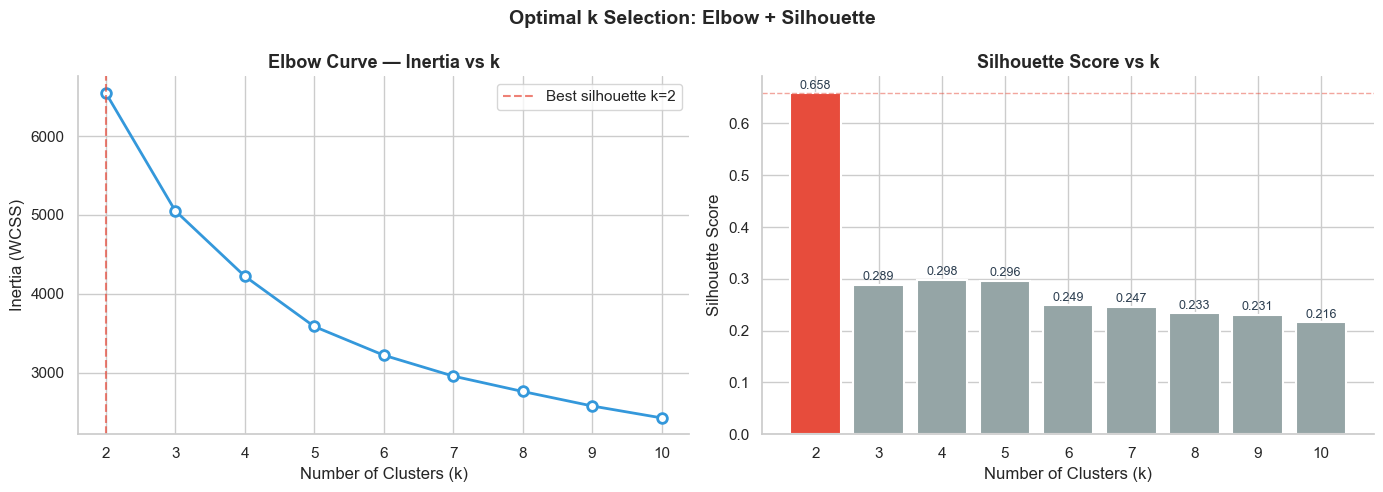

Best k by silhouette: 2  (score=0.6580)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(k_range), inertias, marker='o', color='#3498db',
             linewidth=2, markersize=7, markerfacecolor='white', markeredgewidth=2)
axes[0].set_title('Elbow Curve — Inertia vs k', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(k_range))

# Annotate best k
best_k_sil = list(k_range)[np.argmax(silhouettes)]
axes[0].axvline(best_k_sil, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Best silhouette k={best_k_sil}')
axes[0].legend()

# Silhouette scores
colors = ['#e74c3c' if k == best_k_sil else '#95a5a6' for k in k_range]
bars = axes[1].bar(list(k_range), silhouettes, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Silhouette Score vs k', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))
axes[1].axhline(max(silhouettes), color='#e74c3c', linestyle='--', linewidth=1, alpha=0.5)

for bar, score in zip(bars, silhouettes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=9, color='#2c3e50')

plt.suptitle('Optimal k Selection: Elbow + Silhouette', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/13_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best k by silhouette: {best_k_sil}  (score={max(silhouettes):.4f})')


---
## 4. K-Means Clustering

> We fit K-Means with the selected k, using `n_init=20` to reduce sensitivity to random initialisation. The cluster labels are assigned back to the original customer dataframe for profiling.


In [19]:
# Use best k from silhouette analysis (override here if you prefer a different k)
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)

# Attach labels to original dataframe
df['cluster'] = cluster_labels

print(f'K-Means fitted with k={K}')
print(f'Cluster sizes:')
print(df['cluster'].value_counts().sort_index())
print()
print(f'Overall inertia: {kmeans.inertia_:,.2f}')
print(f'Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}')


K-Means fitted with k=4
Cluster sizes:
cluster
0    512
1    396
2     34
3     41
Name: count, dtype: int64

Overall inertia: 4,225.28
Silhouette score: 0.2983


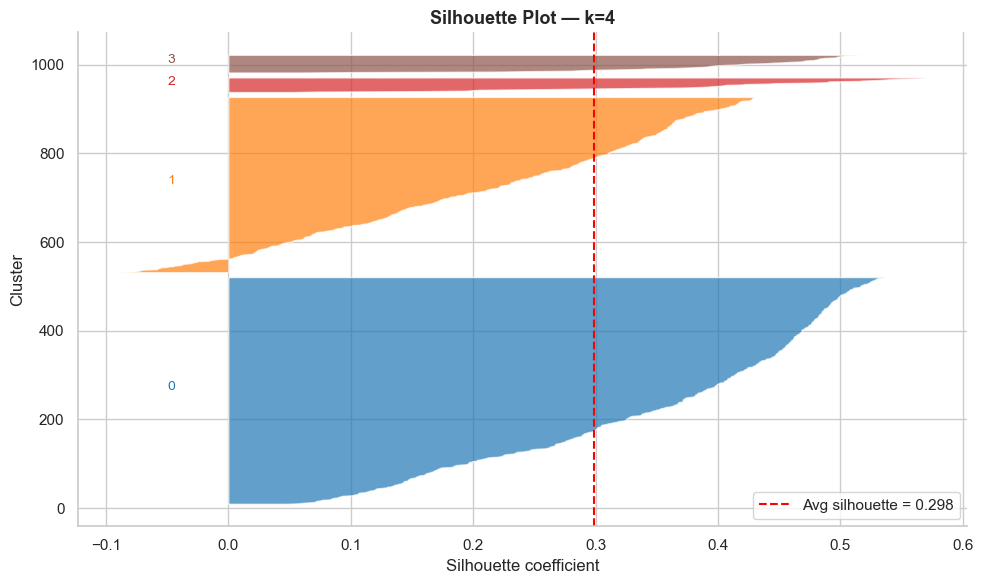

In [20]:
# Silhouette plot — per-sample analysis
fig, ax = plt.subplots(figsize=(10, 6))

sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
cluster_colors = plt.cm.tab10(np.linspace(0, 0.5, K))

y_lower = 10
for i in range(K):
    ith_cluster_sil = sample_silhouette_values[cluster_labels == i]
    ith_cluster_sil.sort()
    size_i = ith_cluster_sil.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil,
                     facecolor=cluster_colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=10, color=cluster_colors[i])
    y_lower = y_upper + 10

avg_score = silhouette_score(X_scaled, cluster_labels)
ax.axvline(avg_score, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg silhouette = {avg_score:.3f}')
ax.set_title(f'Silhouette Plot — k={K}', fontsize=13, fontweight='bold')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.savefig('plots/14_silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Dimensionality Reduction — PCA

> PCA reduces the feature space to 2 principal components for visual inspection. The percentage of variance explained tells us how much information we're preserving in the 2D projection.


In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total (2D):                {pca.explained_variance_ratio_.sum()*100:.1f}%')
print()

# PC loadings — which features drive each component?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=cluster_features
).round(3)
print('Top feature loadings:')
print(loadings.abs().sort_values('PC1', ascending=False).head(8))


Variance explained by PC1: 46.4%
Variance explained by PC2: 16.5%
Total (2D):                62.9%

Top feature loadings:
                    PC1   PC2
unique_merchants  0.425 0.098
recency           0.401 0.188
unique_categories 0.394 0.218
avg_txn_amt       0.384 0.232
frequency         0.352 0.314
monetary          0.321 0.316
std_txn_amt       0.244 0.549
night_txn_pct     0.198 0.219


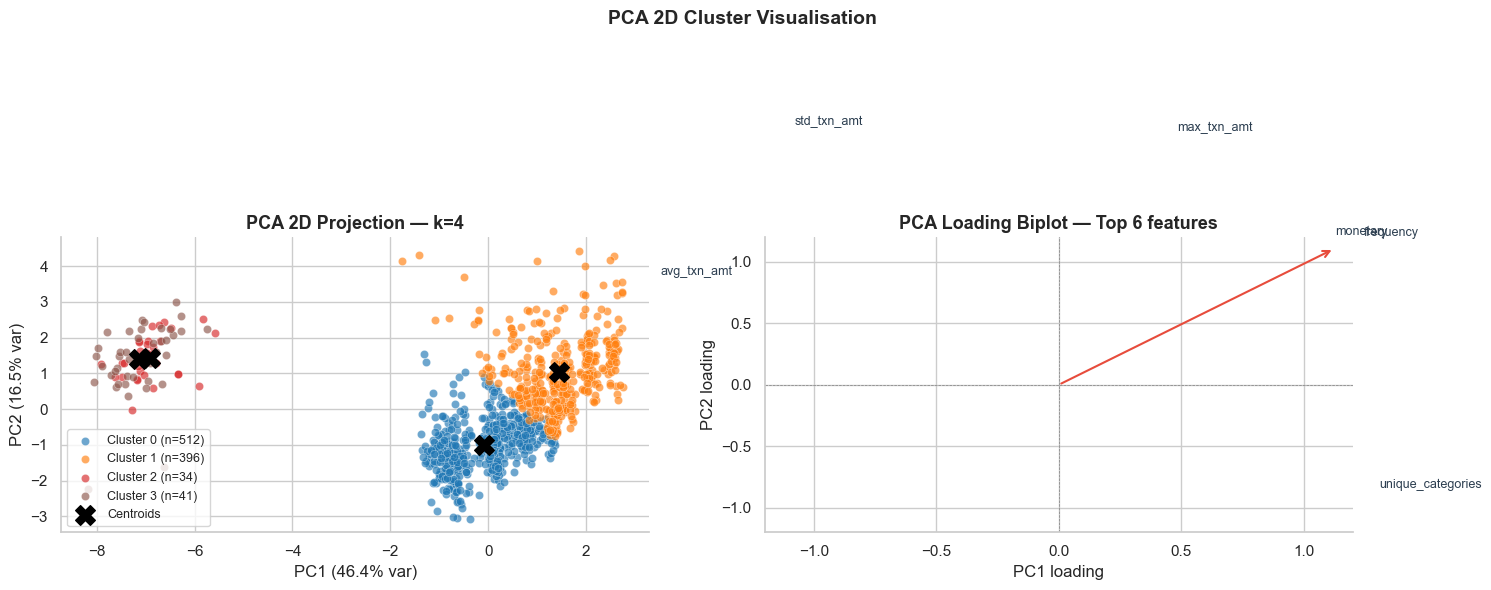

In [22]:
palette = plt.cm.tab10(np.linspace(0, 0.5, K))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA scatter — all points
for c in range(K):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=palette[c], alpha=0.65, s=35,
                    label=f'Cluster {c} (n={mask.sum()})', edgecolors='white', linewidth=0.3)

# Plot centroids projected to PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                color='black', marker='X', s=200, zorder=5, label='Centroids')

axes[0].set_title(f'PCA 2D Projection — k={K}', fontweight='bold', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend(fontsize=9)

# Loading biplot (top 6 features)
top_features = loadings.abs().sum(axis=1).nlargest(6).index
scale = 3.5
for feat in top_features:
    x, y = loadings.loc[feat, 'PC1'] * scale, loadings.loc[feat, 'PC2'] * scale
    axes[1].annotate('', xy=(x, y), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))
    axes[1].text(x * 1.1, y * 1.1, feat, fontsize=9, color='#2c3e50', ha='center')

axes[1].set_title('PCA Loading Biplot — Top 6 features', fontweight='bold', fontsize=13)
axes[1].set_xlabel('PC1 loading')
axes[1].set_ylabel('PC2 loading')
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)

plt.suptitle('PCA 2D Cluster Visualisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/15_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Dimensionality Reduction — t-SNE

> t-SNE is a non-linear method that preserves local neighbourhood structure — it tends to show cluster separation more vividly than PCA. It's slower and non-deterministic (fix `random_state`), but the visual output is typically cleaner for portfolio presentations.
>
> **Note:** t-SNE distances between clusters are not meaningful — only the grouping structure matters.


In [23]:
print('Running t-SNE (this may take 30–60 seconds)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30,
            n_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_scaled)
print('t-SNE complete.')


Running t-SNE (this may take 30–60 seconds)...
t-SNE complete.


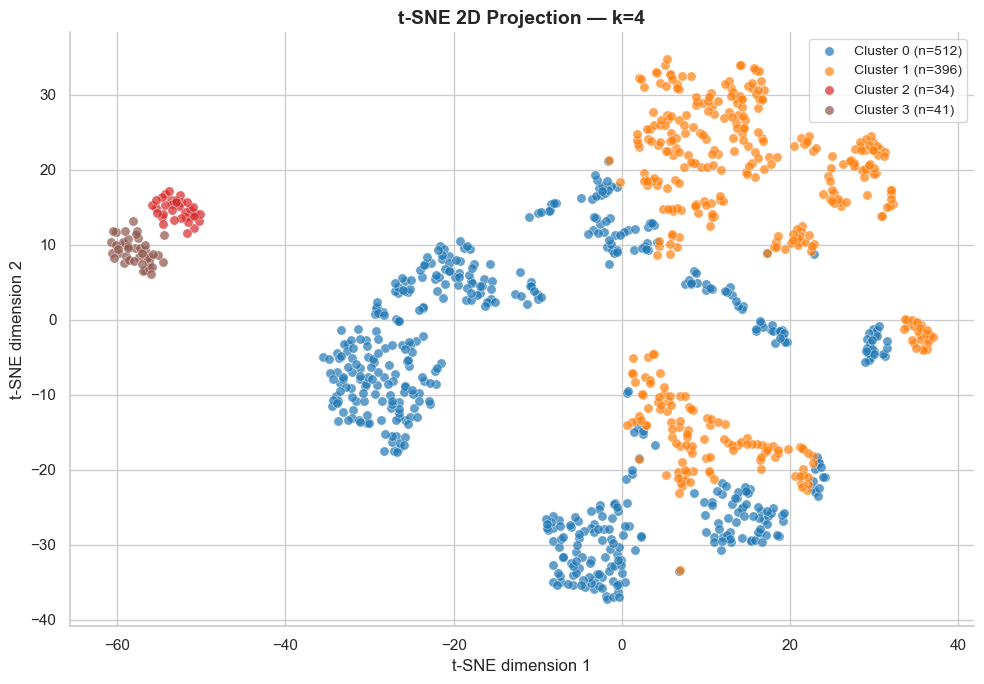

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))

for c in range(K):
    mask = cluster_labels == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               color=palette[c], alpha=0.7, s=45,
               label=f'Cluster {c} (n={mask.sum()})',
               edgecolors='white', linewidth=0.4)

ax.set_title(f't-SNE 2D Projection — k={K}', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plots/16_tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Cluster Profiling

> This is the most important section for business storytelling. We compute the mean of key features per cluster, then name each segment based on its RFM + behavioural signature.
>
> **Naming convention used:** Names should be immediately understandable to a non-technical stakeholder — think "Champions", "At-Risk", not "Cluster 0".


In [25]:
# Mean profile per cluster
profile_cols = rfm_cols + ['avg_txn_amt', 'max_txn_amt', 'night_txn_pct',
                           'weekend_txn_pct', 'unique_merchants', 'fraud_flag', 'customer_age']

profile = df.groupby('cluster')[profile_cols].mean().round(2)
profile['n_customers'] = df['cluster'].value_counts().sort_index()
profile['fraud_rate_pct'] = (profile['fraud_flag'] * 100).round(2)
print(profile.drop(columns='fraud_flag').to_string())


         recency  frequency    monetary  avg_txn_amt  max_txn_amt  night_txn_pct  weekend_txn_pct  unique_merchants  customer_age  n_customers  fraud_rate_pct
cluster                                                                                                                                                       
0          0.260    935.970  66,171.420       71.650    1,617.590          0.230            0.350           457.620        50.890          512          76.000
1          0.030  2,062.420 143,687.480       69.950    4,580.070          0.180            0.350           616.270        42.490          396          75.000
2        250.440      9.940   6,332.910      639.920    1,082.930          0.290            0.790             9.790        55.260           34         100.000
3        296.460      9.830   5,539.080      560.180    1,049.000          0.310            0.010             9.630        60.880           41         100.000


In [26]:
# Normalise profiles for radar chart (0–1 scale per feature)
radar_cols = ['recency', 'frequency', 'monetary', 'avg_txn_amt',
              'night_txn_pct', 'unique_merchants', 'fraud_flag']

profile_norm = profile[radar_cols].copy()
for col in radar_cols:
    col_min = profile_norm[col].min()
    col_max = profile_norm[col].max()
    if col_max > col_min:
        profile_norm[col] = (profile_norm[col] - col_min) / (col_max - col_min)

# Invert recency — lower recency (more recent) = better
profile_norm['recency'] = 1 - profile_norm['recency']
print('Normalised profiles (0=low, 1=high):')
print(profile_norm.round(2))


Normalised profiles (0=low, 1=high):
         recency  frequency  monetary  avg_txn_amt  night_txn_pct  \
cluster                                                             
0          1.000      0.450     0.440        0.000          0.380   
1          1.000      1.000     1.000        0.000          0.000   
2          0.160      0.000     0.010        1.000          0.850   
3          0.000      0.000     0.000        0.860          1.000   

         unique_merchants  fraud_flag  
cluster                                
0                   0.740       0.040  
1                   1.000       0.000  
2                   0.000       1.000  
3                   0.000       1.000  


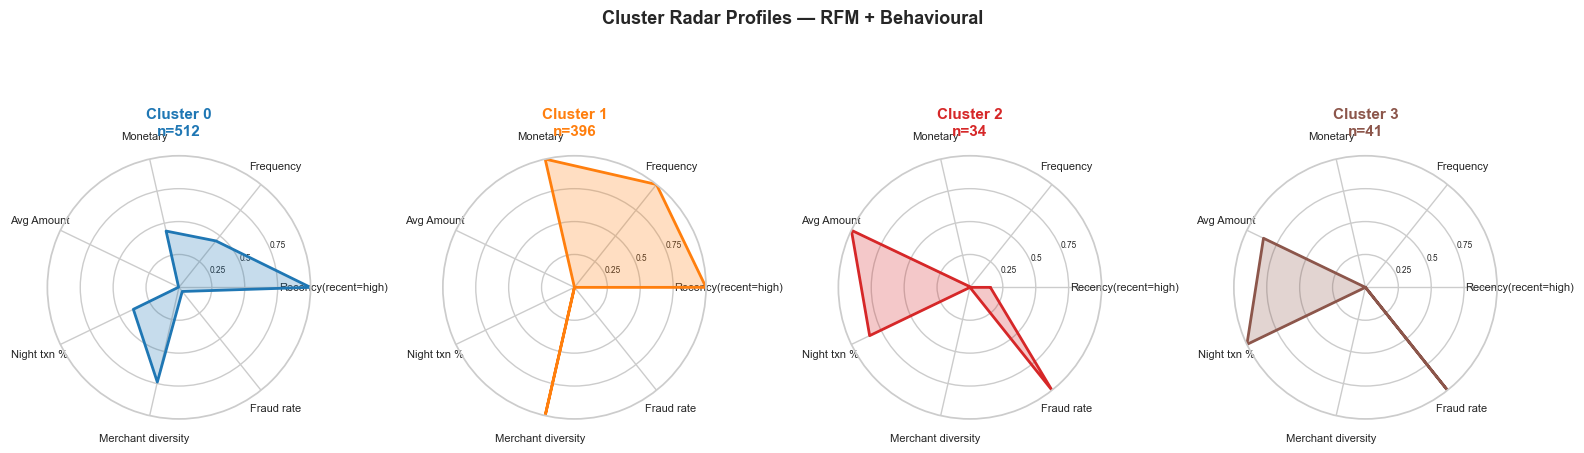

In [27]:
# ── RADAR CHARTS ──
labels = ['Recency(recent=high)', 'Frequency', 'Monetary', 'Avg Amount',
          'Night txn %', 'Merchant diversity', 'Fraud rate']
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, K, figsize=(4 * K, 5), subplot_kw=dict(polar=True))
if K == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    values = profile_norm.iloc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, color=palette[i], linewidth=2)
    ax.fill(angles, values, color=palette[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.5', '0.75'], fontsize=6)
    ax.set_title(f'Cluster {i}\nn={int(profile.loc[i, "n_customers"])}',
                 fontsize=11, fontweight='bold', pad=15, color=palette[i])

plt.suptitle('Cluster Radar Profiles — RFM + Behavioural', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/17_radar_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Segment Naming & Business Narrative



In [28]:
# ── Edit this mapping after reviewing the profile table above ──
# Key = cluster number (int), Value = (name, description, recommendation)

SEGMENT_NAMES = {
    0: (
        'Loyal',
        'Recent, high-frequency, solid lifetime spend (~$66K avg). '
        'Core revenue base at 512 customers.',
        'Maintain engagement with personalised offers. Monitor for any '
        'recency drift — early churn signals should trigger re-engagement.'
    ),
    1: (
        'Champions',
        'Most recent activity, highest frequency (2062 txns avg) and '
        'highest spend ($143K avg). Your top-value segment.',
        'Prioritise retention above all else. Reward loyalty, offer '
        'premium features. These 396 customers likely drive the majority of revenue.'
    ),
    2: (
        'Suspicious',
        'Dormant 250+ days, very low frequency but anomalously high avg '
        'transaction ($640). Weekend-heavy (79%). 100% fraud-flagged.',
        'Immediate fraud review. Large infrequent weekend transactions on '
        'inactive accounts is a textbook fraud pattern. Flag for manual investigation.'
    ),
    3: (
        'Dormant',
        'Inactive ~300 days, minimal transactions, low spend. '
        'Older demographic (avg age 61). 100% fraud-flagged.',
        'Win-back campaign unlikely to succeed given inactivity duration. '
        'Freeze accounts pending fraud review given 100% flag rate.'
    ),
}

# If K != 4, trim or extend the dict to match your actual clusters
SEGMENT_NAMES = {k: v for k, v in SEGMENT_NAMES.items() if k < K}

# Assign names to dataframe
df['segment_name'] = df['cluster'].map({k: v[0] for k, v in SEGMENT_NAMES.items()})

print('=== SEGMENT BUSINESS PROFILES ===\n')
for c, (name, desc, rec) in SEGMENT_NAMES.items():
    n = (df['cluster'] == c).sum()
    fraud_r = df[df['cluster'] == c]['fraud_flag'].mean() * 100
    monetary_med = df[df['cluster'] == c]['monetary'].median()
    print(f'Cluster {c} — {name}  (n={n}, {n/len(df)*100:.1f}%)')
    print(f'  Median lifetime spend : ${monetary_med:,.0f}')
    print(f'  Fraud rate            : {fraud_r:.1f}%')
    print(f'  Description           : {desc}')
    print(f'  Recommendation        : {rec}')
    print()


=== SEGMENT BUSINESS PROFILES ===

Cluster 0 — Loyal  (n=512, 52.1%)
  Median lifetime spend : $63,261
  Fraud rate            : 76.4%
  Description           : Recent, high-frequency, solid lifetime spend (~$66K avg). Core revenue base at 512 customers.
  Recommendation        : Maintain engagement with personalised offers. Monitor for any recency drift — early churn signals should trigger re-engagement.

Cluster 1 — Champions  (n=396, 40.3%)
  Median lifetime spend : $131,733
  Fraud rate            : 74.7%
  Description           : Most recent activity, highest frequency (2062 txns avg) and highest spend ($143K avg). Your top-value segment.
  Recommendation        : Prioritise retention above all else. Reward loyalty, offer premium features. These 396 customers likely drive the majority of revenue.

Cluster 2 — Suspicious  (n=34, 3.5%)
  Median lifetime spend : $6,174
  Fraud rate            : 100.0%
  Description           : Dormant 250+ days, very low frequency but anomalously hig

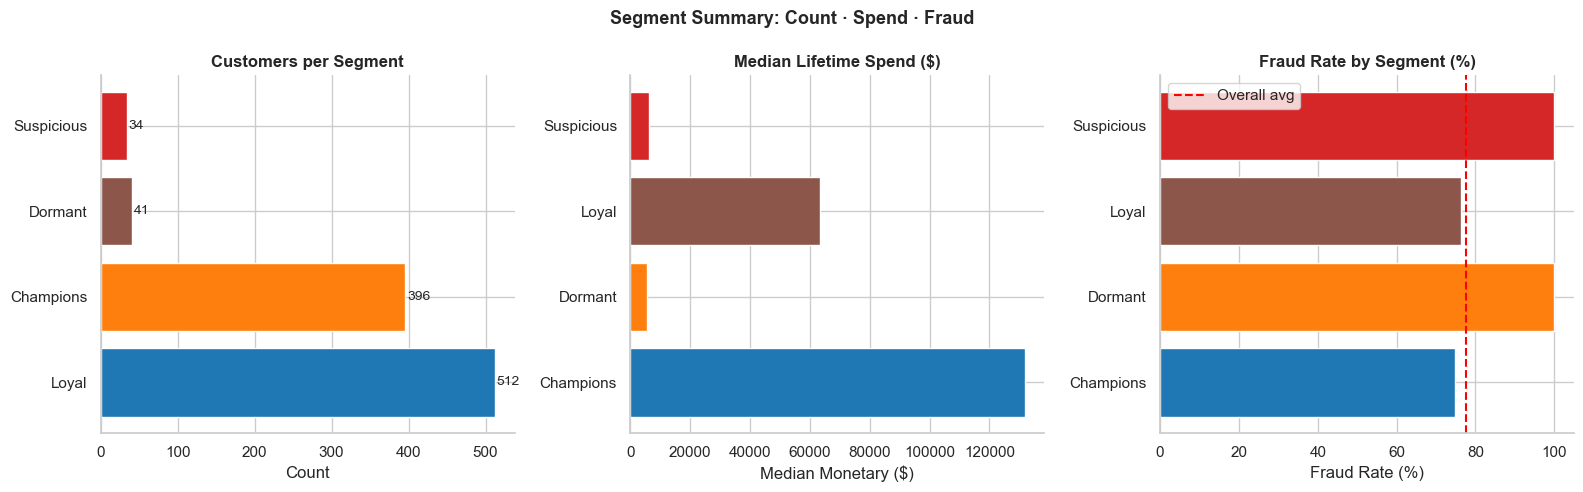

In [29]:
# ── Segment distribution bar chart ──
segment_counts = df['segment_name'].value_counts()
fraud_by_seg = df.groupby('segment_name')['fraud_flag'].mean() * 100
monetary_by_seg = df.groupby('segment_name')['monetary'].median()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
seg_colors = [palette[df[df['segment_name'] == s]['cluster'].iloc[0]] for s in segment_counts.index]

# Count
axes[0].barh(segment_counts.index, segment_counts.values, color=seg_colors, edgecolor='white')
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(segment_counts.values):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=10)

# Median spend
axes[1].barh(monetary_by_seg.index, monetary_by_seg.values, color=seg_colors, edgecolor='white')
axes[1].set_title('Median Lifetime Spend ($)', fontweight='bold')
axes[1].set_xlabel('Median Monetary ($)')

# Fraud rate
axes[2].barh(fraud_by_seg.index, fraud_by_seg.values, color=seg_colors, edgecolor='white')
axes[2].axvline(df['fraud_flag'].mean() * 100, color='red', linestyle='--',
                linewidth=1.5, label=f'Overall avg')
axes[2].set_title('Fraud Rate by Segment (%)', fontweight='bold')
axes[2].set_xlabel('Fraud Rate (%)')
axes[2].legend()

plt.suptitle('Segment Summary: Count · Spend · Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/18_segment_summary.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Feature Distributions by Segment

> Box plots of key RFM and behavioural features split by segment. This is the visual evidence that the clusters are meaningfully separated — not just spatially in PCA space.

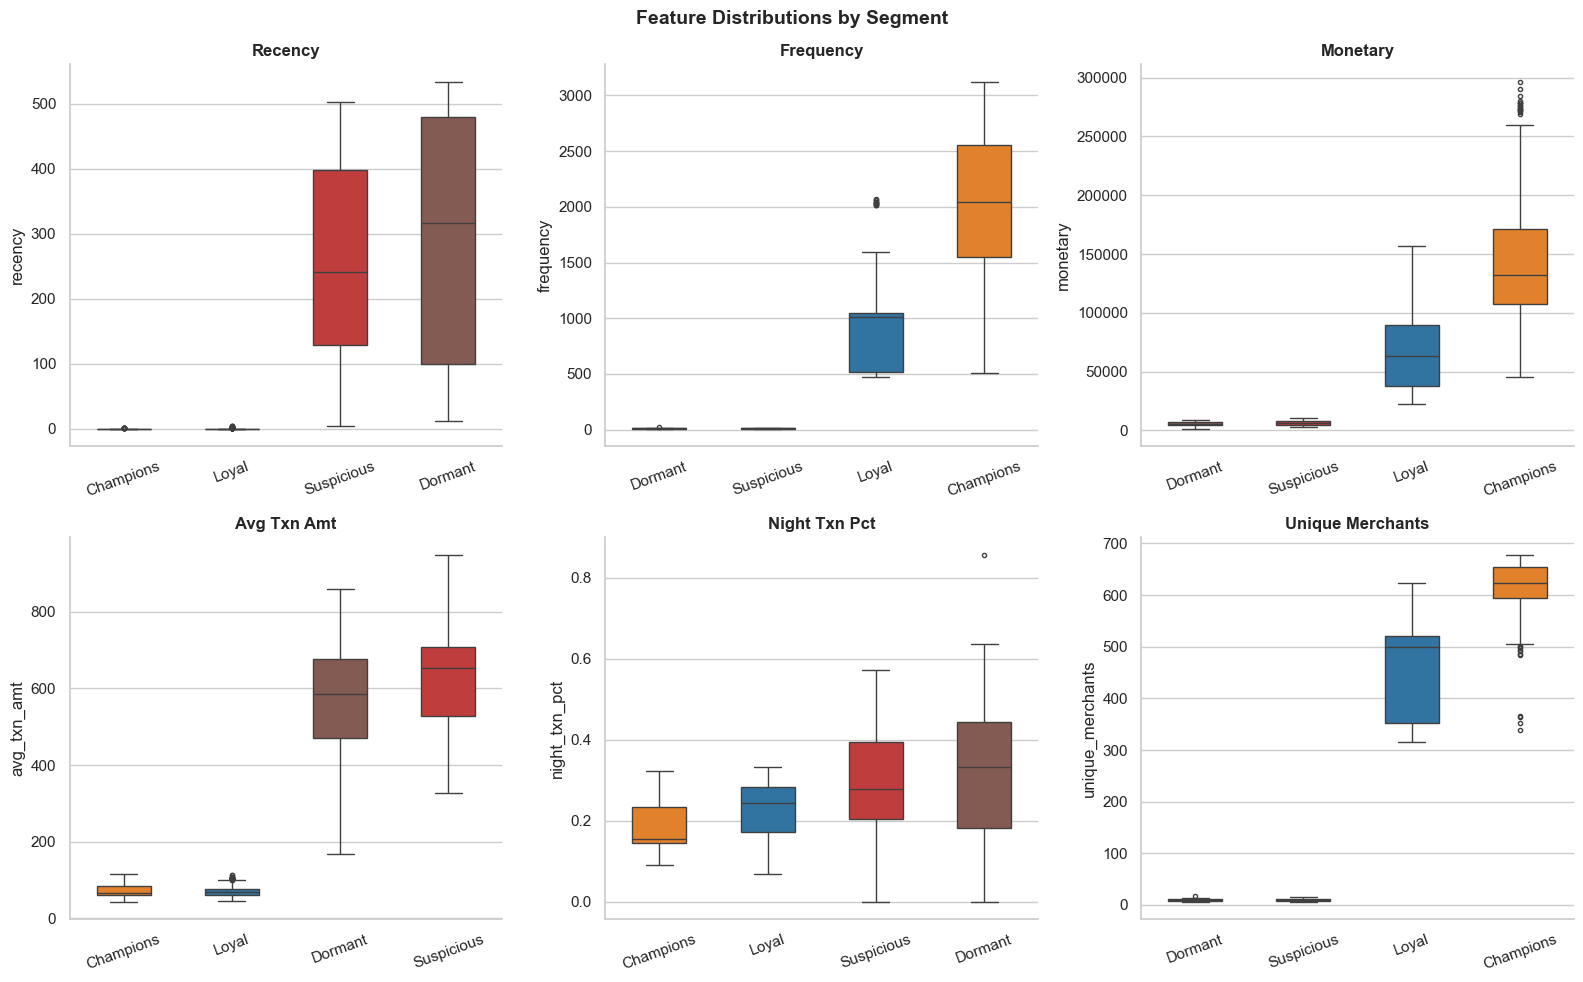

In [30]:
plot_features = ['recency', 'frequency', 'monetary', 'avg_txn_amt', 'night_txn_pct', 'unique_merchants']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    order = df.groupby('segment_name')[feat].median().sort_values().index
    sns.boxplot(data=df, x='segment_name', y=feat, order=order,
                palette={s: palette[df[df['segment_name']==s]['cluster'].iloc[0]] for s in df['segment_name'].unique()},
                ax=axes[i], width=0.5, fliersize=3)
    axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Feature Distributions by Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/19_segment_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 10. Export — customer_segments.csv

> This is the handoff to Phase 3 (Fraud / Churn Modeling). The exported file contains all original features plus `cluster` (int) and `segment_name` (string). Phase 3 will use the cluster label as an additional feature in the fraud detection model, and the segment profiles to stratify train/test splits.


In [31]:
output_path = 'customer_segments.csv'
df.to_csv(output_path, index=False)

print(f'Saved: {output_path}')
print(f'Shape: {df.shape}')
print(f'New columns: cluster, segment_name')
print()
print('Segment distribution in exported file:')
print(df['segment_name'].value_counts())
print()
print('Fraud flag by segment (validation):')
print(df.groupby('segment_name')['fraud_flag'].agg(['sum','mean','count']).rename(
    columns={'sum':'fraud_count','mean':'fraud_rate','count':'total'}).round(3))


Saved: customer_segments.csv
Shape: (983, 24)
New columns: cluster, segment_name

Segment distribution in exported file:
segment_name
Loyal         512
Champions     396
Dormant        41
Suspicious     34
Name: count, dtype: int64

Fraud flag by segment (validation):
              fraud_count  fraud_rate  total
segment_name                                
Champions             296       0.747    396
Dormant                41       1.000     41
Loyal                 391       0.764    512
Suspicious             34       1.000     34


---
## 11. Phase 2 Summary

### What we built
- Preprocessed 983 customer accounts using log-transform + StandardScaler
- Selected optimal k via Elbow + Silhouette analysis
- Fitted K-Means and validated cluster quality with a per-sample silhouette plot
- Projected clusters to 2D using both PCA and t-SNE for visual validation
- Built radar charts and box plots to profile each segment
- Named each segment with a business narrative and recommended action

### Key outputs
| File | Description |
|---|---|
| `customer_segments.csv` | 983 rows, cluster labels appended — input for Phase 3 |
| `plots/13_optimal_k.png` | Elbow + Silhouette k-selection |
| `plots/14_silhouette_plot.png` | Per-sample silhouette analysis |
| `plots/15_pca_clusters.png` | PCA 2D projection + loading biplot |
| `plots/16_tsne_clusters.png` | t-SNE 2D projection |
| `plots/17_radar_profiles.png` | Radar charts per segment |
| `plots/18_segment_summary.png` | Count, spend, fraud by segment |
| `plots/19_segment_distributions.png` | Feature box plots by segment |

### What Phase 3 will use from this notebook
- `cluster` as a categorical feature in XGBoost
- `segment_name` to stratify train/test splits (ensure all segments appear in both)
- Segment fraud rates as a sanity check for model predictions
- Silhouette score as a baseline "unsupervised model quality" metric to report alongside supervised metrics

> **Modeling note:** The 77.5% fraud-flag rate at customer level is very different from the 0.58% transaction-level rate seen in Phase 1. This is because a customer only needs *one* fraudulent transaction to be flagged. Phase 3 should model at the **transaction level** for fraud detection, and optionally at the **customer level** for churn/CLV prediction.
